In [ ]:
import numpy as np

ver = 'GRU'  # GRU or LSTM

date = "mother_folder"
rnn_folder = f"base_path/{date}_DL"

shap_number = "project_name"

look_frame = 10

shap_vals = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_values.npy")

print(shap_vals.shape)

(192, 11, 67584)


In [2]:
roi_number = []
for ic in range(shap_vals.shape[2]):
    roi_number.append(f"IC{ic+1}")

print(roi_number)

['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'IC6', 'IC7', 'IC8', 'IC9', 'IC10', 'IC11', 'IC12', 'IC13', 'IC14', 'IC15', 'IC16', 'IC17', 'IC18', 'IC19', 'IC20', 'IC21', 'IC22', 'IC23']


In [ ]:
fs = 20

start_value = -0.5


increment = 1/fs


count = look_frame+1


t = [start_value + i * increment for i in range(count)]

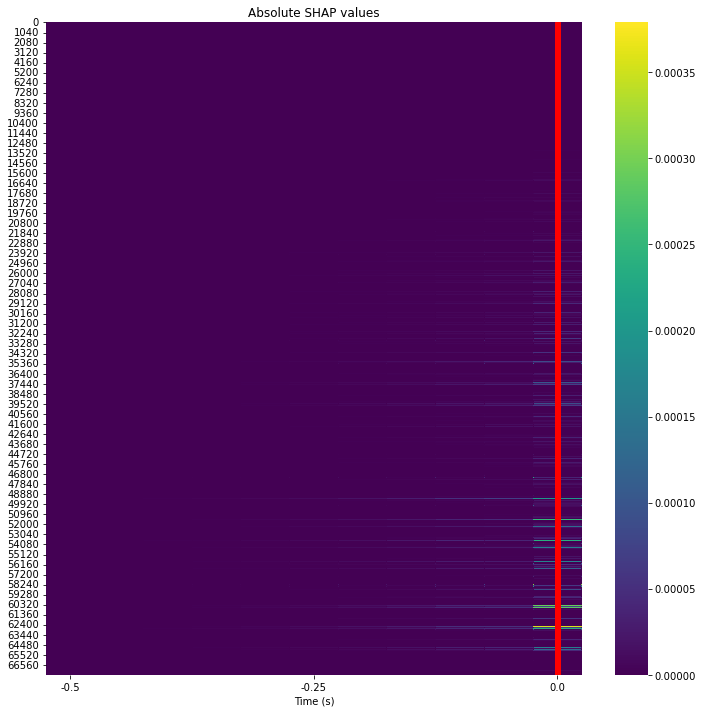

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def show_shap_abs_mean(shap_val):
    s = np.mean(np.abs(shap_val), axis=0).reshape([look_frame+1, shap_vals.shape[2]])
    plt.figure(figsize=(12, 12))
    sns.heatmap(s.transpose(),cmap='viridis')
    #plt.xticks( numpy.arange(0.5,2*look_frame+1.5), numpy.arange(-look_frame,look_frame+1), fontsize=12)
    #plt.xticks(np.arange(0.5,look_frame+1.5, 5), np.arange(-int(look_frame/fs), 1/fs, 5))

    ticks = np.arange(0.5, look_frame + 1.0, 5)

    labels = np.linspace(start_value, 0, len(ticks))
    plt.xticks(ticks, labels)
    #plt.yticks( np.arange(0.5, shap_vals.shape[2]+0.5), roi_number, rotation=0)
    plt.axvspan(10.45, 10.55, color='red', alpha=1)
    plt.title("Absolute SHAP values")
    plt.xlabel("Time (s)")
    #plt.ylabel("IC #")
    plt.show()

show_shap_abs_mean(shap_vals)

In [ ]:
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt



predata = np.sum(np.abs(shap_vals), axis= 1).transpose()
data = predata.tolist()

group_names = [str(i) for i in range(1, predata.shape[0]+1)]
#group_names = areanames

means = [np.mean(group) for group in data]
sems = [stats.sem(group) for group in data]

max_mean_index = np.argmax(means)


p_values = []
for i, group in enumerate(data):
    if i != max_mean_index:
        _, p = stats.ranksums(data[max_mean_index], group)
        p_values.append(p)
    else:
        p_values.append(1) 


_, p_corrected, _, _ = multipletests(p_values, method='holm')

# グラフの作成
plt.figure(figsize=(10, 10))
bars = plt.bar(group_names, means, yerr=sems, capsize=5)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.xlabel("IC #", fontsize=12, labelpad=10) 
plt.ylabel("Sum absolute SHAP values", fontsize=15)

offset1 = 0.03 * max(abs(np.array(means)))
offset2 = 0.12 * max(abs(np.array(means)))


for i, (p, bar) in enumerate(zip(p_corrected, bars)):
    if p>=0.05 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, 'n.s.',
                 ha='center', va='bottom', fontsize=12)
    if p < 0.05 and p>=0.01 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, '*',
                 ha='center', va='bottom', fontsize=12)
    if p < 0.01 and p>=0.005 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, '**',
                 ha='center', va='bottom', fontsize=12)
    if p < 0.005 and i != max_mean_index:
        mean = means[i]
        err = sems[i]
        if mean >= 0:
            height = mean + err + offset1
            va = 'bottom'
        else:
            height = mean - err - offset2
            va = 'top'
        plt.text(bar.get_x() + bar.get_width()/2, height, '***',
                 ha='center', va='bottom', fontsize=12)
        


bars[max_mean_index].set_color('red')
max_mean = means[max_mean_index]
max_sem = sems[max_mean_index]
if max_mean >= 0:
    max_label_height = max_mean + max_sem + offset1
    max_label_va = 'bottom'
else:
    max_label_height = max_mean - max_sem - offset2
    max_label_va = 'top'
plt.text(max_mean_index, max_label_height, 'Max',
         ha='center', va=max_label_va, fontsize=12)


y_min = min(means) - max(sems) * 3
y_max = max(means) + max(sems) * 3
#plt.ylim(y_min, y_max)
plt.ylim(-0.002, y_max)

plt.xticks(range(predata.shape[0]), roi_number, rotation=90)
plt.tick_params(axis='x', which='major', labelsize=15, pad=5)
plt.tick_params(axis='y', which='major', labelsize=15, pad=5)


plt.tight_layout()
plt.show()


results = pd.DataFrame({
    'Group': roi_number,
    'Mean': means,
    'SEM': sems,
    'P-value': p_values,
    'Corrected P-value': p_corrected,
    'Significant': p_corrected < 0.05
})

print("Group {}".format(roi_number[max_mean_index]))
print(results)


non_significant_groups = results[results['Significant'] == False]['Group'].tolist()

print("ROIs")
print(non_significant_groups)

In [ ]:
means_array = np.array(means)


value_map = dict(zip(np.arange(1, roi_number.shape[0]+1).astype(int), means_array))


atlas_int = atlas.astype(int)


#mapped_values = np.vectorize(value_map.get)(atlas_int, 0)
mapped_values = np.array([[value_map.get(val, 0) for val in row] for row in atlas_int])



#plt.imshow(mapped_values)
#plt.show()

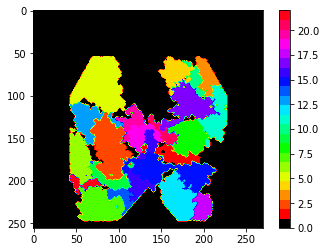

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


base_cmap = plt.cm.get_cmap('hsv', roi_number.shape[0]) 
colors = ['black'] + [base_cmap(i) for i in range(roi_number.shape[0])]
cmap = ListedColormap(colors)

plt.imshow(atlas_int, cmap=cmap)
plt.colorbar()
plt.show()

In [7]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_shap_value_mean.npy", means_array)

NameError: name 'means_array' is not defined